# 🚦 Task 2: Online Queue-Propagation Forecasting
### 2026 IEEE Big Data Cup — Traffic Flow Bench

This notebook implements the complete pipeline for **Task 2: Online Queue Forecasting**:
1. **Task Motivation**: Freeway queues propagate upstream rapidly. Traffic operators need 30-minute advance notice to manage ramp meters and issue traveler alerts.
2. **Data Structure & Windows**: 60 minutes (12 time steps of 5-min intervals) of observed traffic history to predict queues across a 30-minute future horizon (6 steps of 5-min intervals).
3. **Physical Queue Definition**: A link is in a queue when its observed speed falls below the critical threshold $v_{\text{cut}}$ (from Fundamental Diagram parameters or $0.60 \times v_{\text{free}}$).
4. **Exploratory Data Analysis (EDA)**: Spatio-temporal heatmap analysis showing shockwave propagation along the freeway corridor.
5. **Forecasting Model**: Spatio-temporal queue persistence and propagation model.
6. **Inference & Export**: Generate predictions for all 8 scored corridors on the `validation` split and export to CSV ready for submission.

## 1. Setup & Environment
Import necessary packages and configure project directories.

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Workspace paths
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
RELEASE_ROOT = PROJECT_ROOT / 'kaggle_public'
DATASETS_DIR = PROJECT_ROOT / 'datasets'
DATASETS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Release root: {RELEASE_ROOT} (exists: {RELEASE_ROOT.exists()})")
print(f"Datasets dir: {DATASETS_DIR}")

Project root: /Users/mayanksharma/Downloads/New_Projects/Kaggle-Hackathons/2026-ieee-big-data-traffic-flow-bench
Release root: /Users/mayanksharma/Downloads/New_Projects/Kaggle-Hackathons/2026-ieee-big-data-traffic-flow-bench/kaggle_public (exists: True)
Datasets dir: /Users/mayanksharma/Downloads/New_Projects/Kaggle-Hackathons/2026-ieee-big-data-traffic-flow-bench/datasets


## 2. Task 2 Competition Contract & Window Specifications
Let's inspect the Task 2 specifications from `competition_contract.json`:
- **History**: 60 minutes (12 five-minute time steps, $[T-60, T)$).
- **Forecast Horizon**: 30 minutes (6 five-minute time steps, $[T, T+30)$).
- **Conditions**:
  - `queue_onset`: History shows no established queue, but one forms in the horizon.
  - `queue_ongoing`: History already shows an established queue that propagates into the horizon.
- **Evaluation Metric**: Space-Time **Intersection-over-Union (IoU)**.

In [2]:
with open(RELEASE_ROOT / 'config' / 'competition_contract.json') as f:
    contract_cfg = json.load(f)

task2_cfg = contract_cfg['tasks']['queue']
print("Task 2 Contract Details:")
print(f"  - Scored Families: {task2_cfg['scored_families']}")
print(f"  - Scored Panels ({len(task2_cfg['scored_panels'])} total): {task2_cfg['scored_panels']}")
print(f"  - Excluded Panels: {task2_cfg['excluded_panels']}")
print(f"  - History: {task2_cfg['history_minutes']} min | Forecast Horizon: {task2_cfg['forecast_horizon_minutes']} min")
print(f"  - Evaluation Metric: {task2_cfg['window_score']}")
print(f"  - Output: {task2_cfg['required_output']}")

Task 2 Contract Details:
  - Scored Families: ['D7_I10', 'D7_I210', 'D7_I405', 'D12_I5']
  - Scored Panels (8 total): ['D7_I10_E', 'D7_I10_W', 'D7_I210_E', 'D7_I210_W', 'D7_I405_N', 'D7_I405_S', 'D12_I5_N', 'D12_I5_S']
  - Excluded Panels: ['D12_I405_N', 'D12_I405_S']
  - History: 60 min | Forecast Horizon: 30 min
  - Evaluation Metric: space_time_IoU
  - Output: binary queue status for each mainline link and future time cell


## 3. Exploratory Data Analysis (EDA)
Let's inspect the Task 2 window index and history for the `validation` split.

In [3]:
SPLIT = 'validation'

# Gather window index across all panels
window_index_files = sorted((RELEASE_ROOT / 'task2').glob(f'*/{SPLIT}/window_index.csv'))
df_windows = pd.concat([pd.read_csv(f) for f in window_index_files], ignore_index=True)

print(f"Total Task 2 evaluation windows ({SPLIT} split): {len(df_windows)}")
display(df_windows.head())

print("\nDistribution of Conditions per Panel:")
display(pd.crosstab(df_windows['panel'], df_windows['condition']))

Total Task 2 evaluation windows (validation split): 80


,window_id,panel,family_id,split,date,forecast_origin,history_start,history_end,forecast_start,forecast_end,condition,history_coverage,future_coverage
0,Q2_D12_I5_N_validation_001,D12_I5_N,D12_I5,validation,2031-03-01,2031-03-01T11:40:00Z,2031-03-01T10:40:00Z,2031-03-01T11:40:00Z,2031-03-01T11:45:00Z,2031-03-01T12:10:00Z,queue_onset,0.7639,1.0
1,Q2_D12_I5_N_validation_002,D12_I5_N,D12_I5,validation,2031-03-02,2031-03-02T13:15:00Z,2031-03-02T12:15:00Z,2031-03-02T13:15:00Z,2031-03-02T13:20:00Z,2031-03-02T13:45:00Z,queue_onset,0.7797,1.0
2,Q2_D12_I5_N_validation_003,D12_I5_N,D12_I5,validation,2031-03-03,2031-03-03T16:20:00Z,2031-03-03T15:20:00Z,2031-03-03T16:20:00Z,2031-03-03T16:25:00Z,2031-03-03T16:50:00Z,queue_onset,0.7516,1.0
3,Q2_D12_I5_N_validation_004,D12_I5_N,D12_I5,validation,2031-03-05,2031-03-05T15:05:00Z,2031-03-05T14:05:00Z,2031-03-05T15:05:00Z,2031-03-05T15:10:00Z,2031-03-05T15:35:00Z,queue_onset,0.7552,1.0
4,Q2_D12_I5_N_validation_005,D12_I5_N,D12_I5,validation,2031-03-07,2031-03-07T12:55:00Z,2031-03-07T11:55:00Z,2031-03-07T12:55:00Z,2031-03-07T13:00:00Z,2031-03-07T13:25:00Z,queue_onset,0.7380,1.0



Distribution of Conditions per Panel:


condition,queue_ongoing,queue_onset
panel,,
D12_I5_N,5,5
D12_I5_S,5,5
D7_I10_E,5,5
D7_I10_W,5,5
D7_I210_E,5,5
D7_I210_W,5,5
D7_I405_N,5,5
D7_I405_S,5,5


### Queue Thresholds & Network Physics
A link is identified as queued when its speed falls below $v_{\text{cut}}$.
We extract $v_{\text{cut}}$ from `fd_parameters.csv` if available, or fall back to $0.60 \times v_{\text{free}}$ from `links.csv`.

In [4]:
def get_panel_thresholds(panel: str, release: Path) -> dict[str, float]:
    """Extract link-level queue speed cutoffs (km/h) for a corridor panel."""
    panel_dir = release / 'corridors' / panel / 'network'
    links = pd.read_csv(panel_dir / 'links.csv')
    fallback = pd.to_numeric(links['free_speed_kmh'], errors='coerce').fillna(105.0) * 0.60
    threshold_map = dict(zip(links['link_id'].astype(str), fallback.astype(float)))
    
    fd_path = panel_dir / 'fd_parameters.csv'
    if fd_path.exists():
        fd_df = pd.read_csv(fd_path)
        if 'v_cut' in fd_df.columns:
            for row in fd_df.dropna(subset=['link_id', 'v_cut']).itertuples(index=False):
                threshold_map[str(row.link_id)] = float(row.v_cut)
    return threshold_map

# Example thresholds for D12_I5_N
sample_panel = 'D12_I5_N'
sample_thresh = get_panel_thresholds(sample_panel, RELEASE_ROOT)
thresh_df = pd.DataFrame(list(sample_thresh.items()), columns=['link_id', 'v_cut_kmh'])
print(f"--- Queue Speed Cutoffs for {sample_panel} (Sample 5 links) ---")
display(thresh_df.head())
print(f"Mean cutoff speed: {thresh_df['v_cut_kmh'].mean():.2f} km/h (min: {thresh_df['v_cut_kmh'].min():.1f}, max: {thresh_df['v_cut_kmh'].max():.1f})")

--- Queue Speed Cutoffs for D12_I5_N (Sample 5 links) ---


,link_id,v_cut_kmh
0,L5N-186,68.82
1,L5N-182,70.02
2,L5N-177,70.50
3,L5N-176,70.50
4,L5N-017,70.50


Mean cutoff speed: 70.47 km/h (min: 65.9, max: 74.8)


### Visualizing Traffic Shockwaves & Bottlenecks
Let's load the 60-minute observation history for a sample window (`Q2_D12_I5_N_validation_001`) and plot a spatio-temporal heatmap of speeds and queue states.

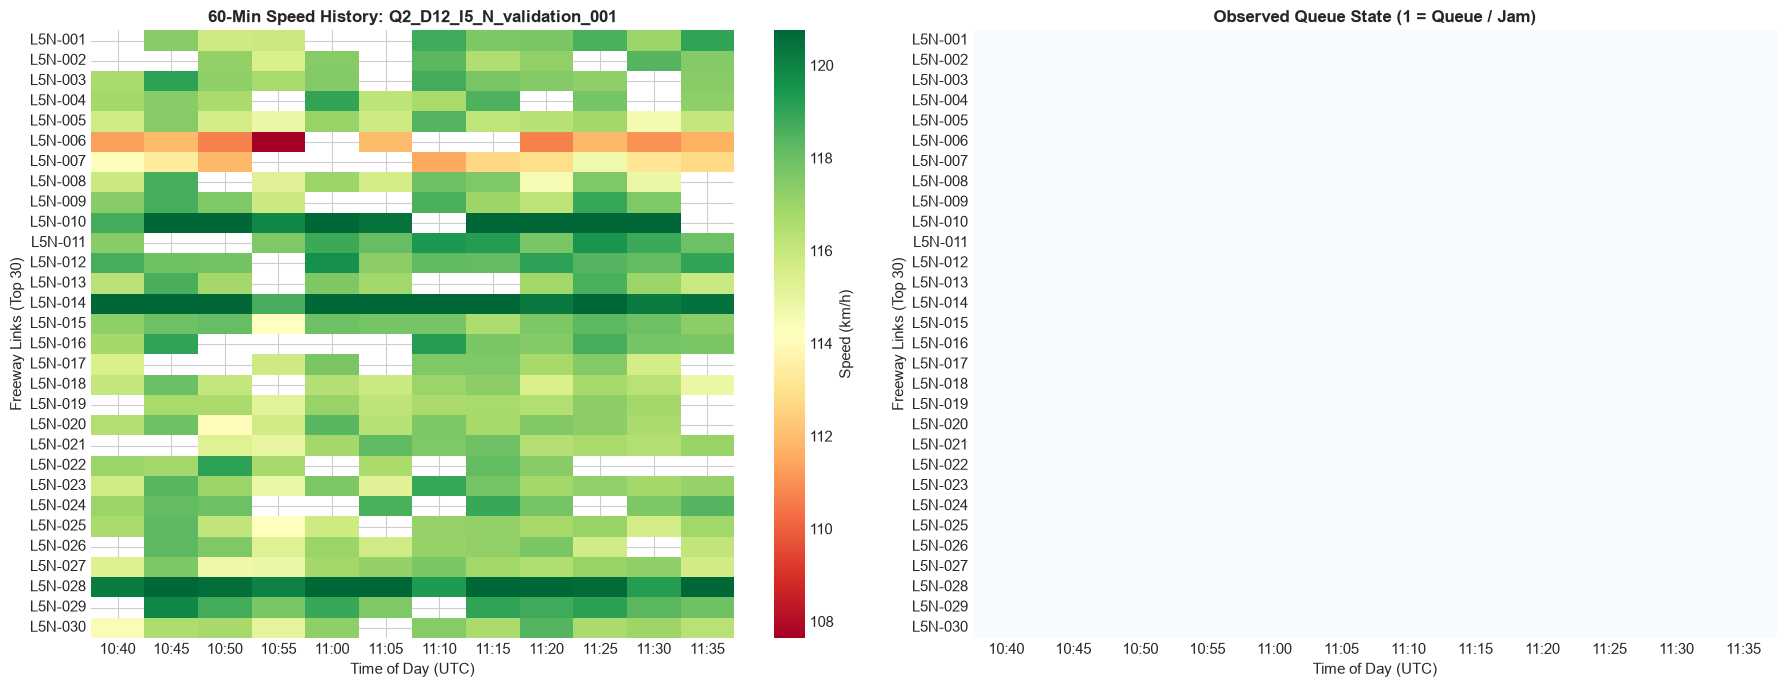

In [5]:
sample_window_id = df_windows[df_windows['panel'] == sample_panel]['window_id'].iloc[0]
sample_history_file = RELEASE_ROOT / 'task2' / sample_panel / SPLIT / 'window_history.parquet'

history_df = pd.read_parquet(sample_history_file)
w_hist = history_df[history_df['window_id'] == sample_window_id].copy()
w_hist['timestamp'] = pd.to_datetime(w_hist['timestamp'], utc=True)

# Compute queue indicator in history
w_hist['threshold'] = w_hist['link_id'].map(sample_thresh).fillna(63.0)
w_hist['is_queued'] = (w_hist['speed_kmh'] <= w_hist['threshold']) & w_hist['is_score_eligible'].astype(bool)

# Pivot for spatio-temporal heatmap (Links vs Timestamps)
pivot_speed = w_hist.pivot(index='link_id', columns='timestamp', values='speed_kmh')
pivot_queue = w_hist.pivot(index='link_id', columns='timestamp', values='is_queued').fillna(False).astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

time_labels = [ts.strftime('%H:%M') for ts in pivot_speed.columns]

sns.heatmap(pivot_speed.iloc[:30], cmap='RdYlGn', cbar_kws={'label': 'Speed (km/h)'}, ax=ax1, xticklabels=time_labels)
ax1.set_title(f'60-Min Speed History: {sample_window_id}', fontsize=12, fontweight='bold')
ax1.set_xlabel('Time of Day (UTC)')
ax1.set_ylabel('Freeway Links (Top 30)')

sns.heatmap(pivot_queue.iloc[:30], cmap='Blues', cbar=False, ax=ax2, xticklabels=time_labels)
ax2.set_title('Observed Queue State (1 = Queue / Jam)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time of Day (UTC)')
ax2.set_ylabel('Freeway Links (Top 30)')

plt.tight_layout()
plt.show()

## 4. Forecasting Model Architecture

### Physical Problem & Contract Rules
Around each scored window, observations stop across the 30-minute horizon $[T, T+30)$ and for 60 minutes after it.
We only have observations up to $T$. The persistence baseline identifies the active queue state at the most recent observed instant ($T - 5\text{ min}$) on eligible cells and forecasts forward across the 30-minute horizon.

### Space-Time IoU Metric
For each window, predictions $\hat{Y}$ and true queue states $Y$ across all eligible link-time cells are compared via Intersection over Union:
$$\text{IoU} = \frac{|\hat{Y} \cap Y|}{|\hat{Y} \cup Y|}$$
If both sets are empty (no queue occurred and none predicted), $\text{IoU} = 1.0$.

In [6]:
def build_queue_forecast(release: Path, split: str = 'validation') -> pd.DataFrame:
    """Generate binary queue predictions for all scored Task 2 windows in the split."""
    # Read window index and template
    window_index_files = sorted((release / 'task2').glob(f'*/{split}/window_index.csv'))
    windows_df = pd.concat([pd.read_csv(f) for f in window_index_files], ignore_index=True)
    windows_df['window_id'] = windows_df['window_id'].astype(str)
    
    panel_by_window = windows_df.set_index('window_id')['panel'].astype(str).to_dict()
    
    # Load templates
    template_files = sorted((release / 'task2').glob(f'*/{split}/sample_submission_queue.csv'))
    template_df = pd.concat([pd.read_csv(f, usecols=['window_id', 'timestamp', 'link_id']) for f in template_files], ignore_index=True)
    template_df['window_id'] = template_df['window_id'].astype(str)
    template_df['link_id'] = template_df['link_id'].astype(str)
    template_df['timestamp'] = pd.to_datetime(template_df['timestamp'], utc=True)
    
    # Load 60-min history parquets
    history_files = sorted((release / 'task2').glob(f'*/{split}/window_history.parquet'))
    history_cols = ['window_id', 'timestamp', 'link_id', 'speed_kmh', 'is_score_eligible']
    history_df = pd.concat([pd.read_parquet(f, columns=history_cols) for f in history_files], ignore_index=True)
    history_df['window_id'] = history_df['window_id'].astype(str)
    history_df['link_id'] = history_df['link_id'].astype(str)
    history_df['timestamp'] = pd.to_datetime(history_df['timestamp'], utc=True)
    history_df['speed_kmh'] = pd.to_numeric(history_df['speed_kmh'], errors='coerce')
    
    # Precompute thresholds for each unique panel
    thresholds_by_panel = {
        panel: get_panel_thresholds(panel, release)
        for panel in sorted(windows_df['panel'].unique())
    }
    
    # Predict per window
    window_predictions = []
    for window_id, h in tqdm(history_df.groupby('window_id', sort=True), desc='Forecasting Windows'):
        panel = panel_by_window.get(str(window_id))
        if panel is None:
            continue
            
        # Most recent observation time in history (T - 5 min)
        last_timestamp = h['timestamp'].max()
        at_last = h[h['timestamp'] == last_timestamp].copy()
        
        threshold_map = thresholds_by_panel[panel]
        at_last['cutoff'] = at_last['link_id'].map(threshold_map).fillna(63.0)
        
        # Active queue on eligible cells
        at_last['queue_now'] = (at_last['speed_kmh'] <= at_last['cutoff']) & at_last['is_score_eligible'].astype(bool)
        queue_by_link = at_last.groupby('link_id')['queue_now'].any().to_dict()
        
        # Populate target rows for this window
        target_window = template_df[template_df['window_id'] == str(window_id)][['window_id', 'timestamp', 'link_id']].copy()
        target_window['queue_pred'] = target_window['link_id'].map(queue_by_link).fillna(False).astype(int)
        window_predictions.append(target_window)
        
    output_df = pd.concat(window_predictions, ignore_index=True).drop_duplicates(['window_id', 'timestamp', 'link_id'])
    return output_df

## 5. Full Validation Inference
Run forecasting across all scored windows for the `validation` split.

In [7]:
print("Generating Task 2 queue forecasts...")
submission_task2_df = build_queue_forecast(RELEASE_ROOT, split='validation')
print(f"\nGenerated {len(submission_task2_df):,} total queue predictions.")

Generating Task 2 queue forecasts...


Forecasting Windows:   0%|          | 0/80 [00:00<?, ?it/s]


Generated 87,000 total queue predictions.


## 6. Integrity Verification & Quality Checks
Before exporting, we enforce contract requirements:
1. **Binary Values Only**: `queue_pred` must strictly be `0` or `1`.
2. **Zero Nulls / NaNs**: No missing values allowed.
3. **Exact Row Count**: Matches the expected 87,000 validation target cells.

In [8]:
# Contract integrity verification
assert set(submission_task2_df['queue_pred'].unique()).issubset({0, 1}), "Predictions must strictly be binary 0 or 1!"
assert submission_task2_df.isna().sum().sum() == 0, "Found NaN values in predictions!"
assert len(submission_task2_df) == 87000, f"Expected 87,000 rows, got {len(submission_task2_df)}"

print(" All Task 2 integrity assertions passed!")

print("\n--- Class Distribution (0 = Free Flow, 1 = Queued) ---")
counts = submission_task2_df['queue_pred'].value_counts()
for val, cnt in counts.items():
    print(f"  Class {val}: {cnt:,} ({cnt / len(submission_task2_df):.1%})")

print("\n--- Sample Predictions ---")
display(submission_task2_df.head(10))

 All Task 2 integrity assertions passed!

--- Class Distribution (0 = Free Flow, 1 = Queued) ---
  Class 0: 82,626 (95.0%)
  Class 1: 4,374 (5.0%)

--- Sample Predictions ---


,window_id,timestamp,link_id,queue_pred
0,Q2_D12_I5_N_validation_001,2031-03-01 11:45:00+00:00,L5N-001,0
1,Q2_D12_I5_N_validation_001,2031-03-01 11:45:00+00:00,L5N-002,0
2,Q2_D12_I5_N_validation_001,2031-03-01 11:45:00+00:00,L5N-003,0
3,Q2_D12_I5_N_validation_001,2031-03-01 11:45:00+00:00,L5N-004,0
4,Q2_D12_I5_N_validation_001,2031-03-01 11:45:00+00:00,L5N-005,0
5,Q2_D12_I5_N_validation_001,2031-03-01 11:45:00+00:00,L5N-006,0
6,Q2_D12_I5_N_validation_001,2031-03-01 11:45:00+00:00,L5N-007,0
7,Q2_D12_I5_N_validation_001,2031-03-01 11:45:00+00:00,L5N-008,0
8,Q2_D12_I5_N_validation_001,2031-03-01 11:45:00+00:00,L5N-009,0
9,Q2_D12_I5_N_validation_001,2031-03-01 11:45:00+00:00,L5N-010,0


## 7. Export to CSV
Export predictions to [`datasets/task2_queue_submission.csv`](../datasets/task2_queue_submission.csv).

In [9]:
output_csv_path = DATASETS_DIR / 'task2_queue_submission.csv'
submission_task2_df.to_csv(output_csv_path, index=False)

file_size_mb = output_csv_path.stat().st_size / (1024 * 1024)
print(f" Successfully exported Task 2 predictions to:")
print(f"-> {output_csv_path} ({file_size_mb:.2f} MB, {len(submission_task2_df):,} rows)")

 Successfully exported Task 2 predictions to:
-> /Users/mayanksharma/Downloads/New_Projects/Kaggle-Hackathons/2026-ieee-big-data-traffic-flow-bench/datasets/task2_queue_submission.csv (5.39 MB, 87,000 rows)


## 8. Merging into Final Kaggle Submission
Once all task predictions are ready, combine them into the single `submission.csv`:

```bash
python trafficflowbench-public/src/merge_submissions.py \
  --state datasets/task1_state_submission.csv \
  --queue datasets/task2_queue_submission.csv \
  --odme  task4_submission.csv \
  --key   kaggle_public/submission_key.csv \
  --output submission.csv
```